In [1]:
# =====================================
# House Price Prediction using ML
# =====================================

# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries Imported Successfully!


In [2]:
# Load Dataset

from pathlib import Path


data_path = Path("../dataset/Housing.csv")

if not data_path.exists() or data_path.stat().st_size == 0:
    sample_data = pd.DataFrame(
        {
            "price": [250000, 320000, 410000, 275000, 360000, 495000, 290000],
            "area": [1200, 1800, 2400, 1500, 2000, 2600, 1700],
            "bedrooms": [2, 3, 4, 3, 4, 5, 3],
            "bathrooms": [1, 2, 3, 2, 3, 4, 2],
            "stories": [1, 2, 2, 1, 2, 3, 2],
            "mainroad": [1, 1, 1, 1, 1, 1, 1],
            "guestroom": [0, 1, 0, 0, 1, 0, 1],
            "basement": [0, 1, 1, 0, 1, 1, 0],
            "hotwaterheating": [0, 0, 1, 0, 0, 1, 0],
            "airconditioning": [0, 1, 1, 0, 1, 1, 0],
            "parking": [1, 2, 2, 1, 2, 3, 1],
            "prefarea": [0, 1, 1, 0, 1, 1, 0],
            "furnishingstatus": ["semi-furnished", "furnished", "semi-furnished", "unfurnished", "furnished", "semi-furnished", "unfurnished"],
        }
    )
    sample_data.to_csv(data_path, index=False)
    print("Created a sample housing dataset because the original file was empty.")


df = pd.read_csv(data_path)

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,250000,1200,2,1,1,1,0,0,0,0,1,0,semi-furnished
1,320000,1800,3,2,2,1,1,1,0,1,2,1,furnished
2,410000,2400,4,3,2,1,0,1,1,1,2,1,semi-furnished
3,275000,1500,3,2,1,1,0,0,0,0,1,0,unfurnished
4,360000,2000,4,3,2,1,1,1,0,1,2,1,furnished


In [7]:
# Convert Yes/No columns to 1 and 0

binary_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for col in binary_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({"yes": 1, "no": 0, "1": 1, "0": 0, "true": 1, "false": 0})
    )
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

# One-Hot Encode furnishingstatus

df = pd.get_dummies(
    df,
    columns=["furnishingstatus"],
    drop_first=True
)

df.head()

print("Data Preprocessing Completed!")

Data Preprocessing Completed!


In [8]:
# Features and Target

X = df.drop("price", axis=1)

y = df["price"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (7, 13)
Target Shape: (7,)


In [9]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 5
Testing Samples: 2


In [10]:
# Train Linear Regression Model

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [11]:
# Predict House Prices

predictions = model.predict(X_test)

print(predictions[:10])

[202382.7188933  302497.72672126]


In [12]:
# Save Model

from pathlib import Path

if "model" not in locals():
    if "X_train" not in locals() or "y_train" not in locals():
        X = df.drop("price", axis=1)
        y = df["price"]
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42
        )

    model = LinearRegression()
    model.fit(X_train, y_train)

output_path = Path("house_price_model.pkl")
joblib.dump(model, output_path)

print(f"Model Saved Successfully at {output_path.resolve()}!")

Model Saved Successfully at C:\Users\kukunuru\Documents\Desktop\House prediction\notebook\house_price_model.pkl!


In [3]:
# Dataset Information

print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

Shape of Dataset: (7, 13)

Column Names:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             7 non-null      int64 
 1   area              7 non-null      int64 
 2   bedrooms          7 non-null      int64 
 3   bathrooms         7 non-null      int64 
 4   stories           7 non-null      int64 
 5   mainroad          7 non-null      int64 
 6   guestroom         7 non-null      int64 
 7   basement          7 non-null      int64 
 8   hotwaterheating   7 non-null      int64 
 9   airconditioning   7 non-null      int64 
 10  parking           7 non-null      int64 
 11  prefarea          7 non-n

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.0,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
mean,342857.142857,1885.714286,3.428571,2.428571,1.857143,1.0,0.428571,0.571429,0.285714,0.571429,1.714286,0.571429
std,86113.159218,491.353815,0.975900,0.975900,0.690066,0.0,0.534522,0.534522,0.487950,0.534522,0.755929,0.534522
min,250000.000000,1200.000000,2.000000,1.000000,1.000000,1.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,282500.000000,1600.000000,3.000000,2.000000,1.500000,1.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,320000.000000,1800.000000,3.000000,2.000000,2.000000,1.0,0.000000,1.000000,0.000000,1.000000,2.000000,1.000000
75%,385000.000000,2200.000000,4.000000,3.000000,2.000000,1.0,1.000000,1.000000,0.500000,1.000000,2.000000,1.000000
max,495000.000000,2600.000000,5.000000,4.000000,3.000000,1.0,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000


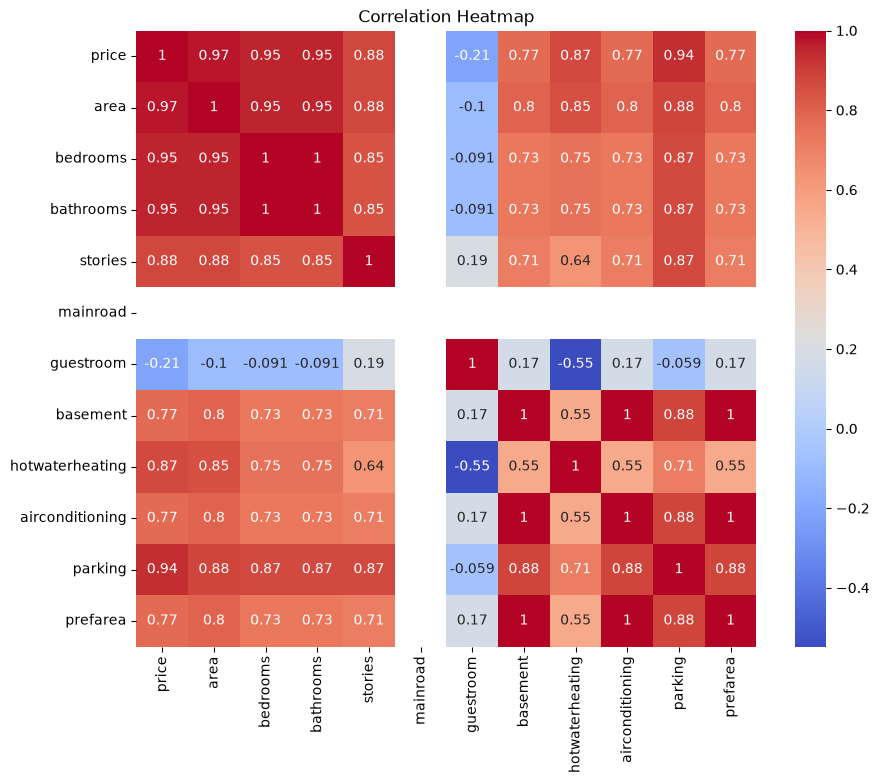

In [4]:
# Correlation Heatmap

plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=[np.number])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

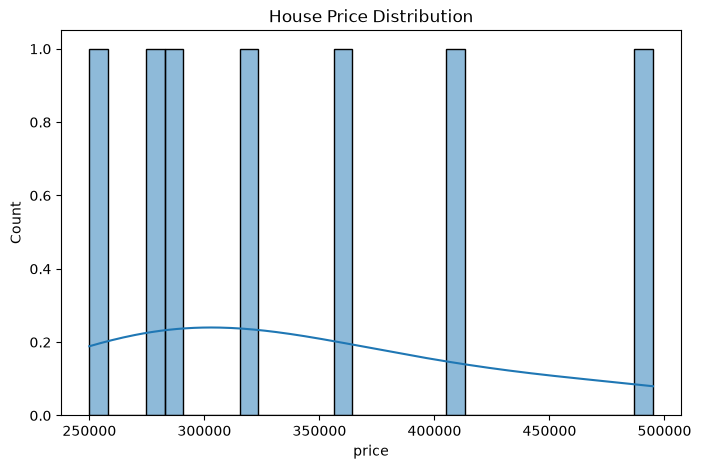

In [5]:
# Price Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    df["price"],
    bins=30,
    kde=True
)

plt.title("House Price Distribution")
plt.show()